# T1 · Bottleneck and the closed episode

| | |
| --- | --- |
| **Paper** | Section 2.2, Eqs. (3)–(4); Fig. 4. |
| **Prerequisites** | Cumulative arrival and departure curves; integrals. |
| **Input units** | time h, flow veh/h/lane, delay h (printed in min). |
| **Expected outputs** | Oblique cumulative curves; D = μP; W_P = ∫Q dt = D·w̄; the 9/16 ratio for the Newell model and a different ratio for another closed profile. |
| **Conditions** | Point queue with a constant service rate μ; the queue is closed (Q = 0 at onset and clearance); first in, first out. |

Template: question, assumptions, derivation, worked example, figure, interpretation question.

## 1. Question
How do the inflow, the service rate, the queue and the delay connect over one bottleneck episode, and which summary of the delay profile is enough for totals?

## 2. Assumptions
A bottleneck serves at a constant rate $\mu$ from onset $t_0$ to clearance $t_3$; arrivals $\lambda(t)$ exceed $\mu$ early and fall below it later; the queue is empty at $t_0$ and $t_3$; vehicles leave in arrival order.

## 3. Derivation
Queue balance $\dot Q=\lambda-\mu$ and FIFO give the delay $w(t)=Q(t)/\mu$. Integrating over the episode with $Q(t_0)=Q(t_3)=0$:
$$D=\int\lambda\,dt=\mu P,\qquad W_P=\int\lambda w\,dt=\int Q\,dt=D\,\bar w_P,\qquad \bar w_P=\frac1P\int w\,dt.$$
The middle identity uses $\lambda w=\mu w+\tfrac{\mu}{2}\tfrac{d}{dt}w^2$, whose last term integrates to zero on a closed queue. So the time-average delay equals the vehicle-average delay, which is what emission totals need.

Newell's quadratic inflow, $Q=\tfrac b3(t-t_0)^2(t_3-t)$, gives a peak at $t_2=t_0+2P/3$ and $\bar w_P/w_{t_2}=9/16$. **The 9/16 ratio belongs to this model only**; another closed profile gives another ratio.

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'qvdfe').exists())
sys.path.insert(0, str(ROOT / 'src'))          # works with or without `pip install -e .`
import json
import numpy as np
import matplotlib.pyplot as plt
import qvdfe
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

def check(name, ok):
    print(('PASS  ' if ok else 'FAIL  ') + name)
    assert ok, name
RATES = qvdfe.load_rates()

## 4. Worked example
The inputs are those of `examples/01_synthetic_episode/config.json` (synthetic values).

In [2]:
cfg = json.loads((ROOT / 'examples/01_synthetic_episode/config.json').read_text())
mu, P, b = cfg['mu_vphpl'], cfg['P_h'], cfg['newell_b_veh_per_h3']
n = qvdfe.NewellQueue(mu=mu, P=P, b=b)
t = np.linspace(0, P, 4001)
q = qvdfe.closed_queue(t, n.lam(t), mu)
print(f"D = {q['D']:.3f} veh/lane (mu P = {mu*P:.0f});  W_P = {q['W_P']:.4f} veh h/lane;  D * mean delay = {q['D']*q['mean_delay_vehicle']:.4f}")
print(f"time-average delay {q['mean_delay_time']*60:.4f} min, vehicle-average delay {q['mean_delay_vehicle']*60:.4f} min")
check('vehicle conservation D = mu P', np.isclose(q['D'], mu * P, rtol=1e-8))
check('closed queue Q(t3) = 0', q['closure_error'] < 1e-6 * mu * P)
check('W_P = integral of Q = D * mean delay', np.isclose(q['W_P'], q['D'] * q['mean_delay_vehicle'], rtol=1e-4))
check('Newell model: mean/peak delay = 9/16', np.isclose(n.mean_delay / n.peak_delay, 9 / 16))
# a second closed profile with the same mu and P: sinusoidal surplus
lam2 = mu + 120 * np.sin(2 * np.pi * t / P)
q2 = qvdfe.closed_queue(t, lam2, mu)
print(f"sinusoidal profile: mean/peak = {q2['mean_delay_time'] / q2['w'].max():.4f}  (not 9/16)")
check('second profile is closed too', q2['closure_error'] < 1e-6 * mu * P)

D = 3000.000 veh/lane (mu P = 3000);  W_P = 44.4444 veh h/lane;  D * mean delay = 44.4444
time-average delay 0.8889 min, vehicle-average delay 0.8889 min
PASS  vehicle conservation D = mu P
PASS  closed queue Q(t3) = 0
PASS  W_P = integral of Q = D * mean delay
PASS  Newell model: mean/peak delay = 9/16
sinusoidal profile: mean/peak = 0.5000  (not 9/16)
PASS  second profile is closed too


## 5. Figure

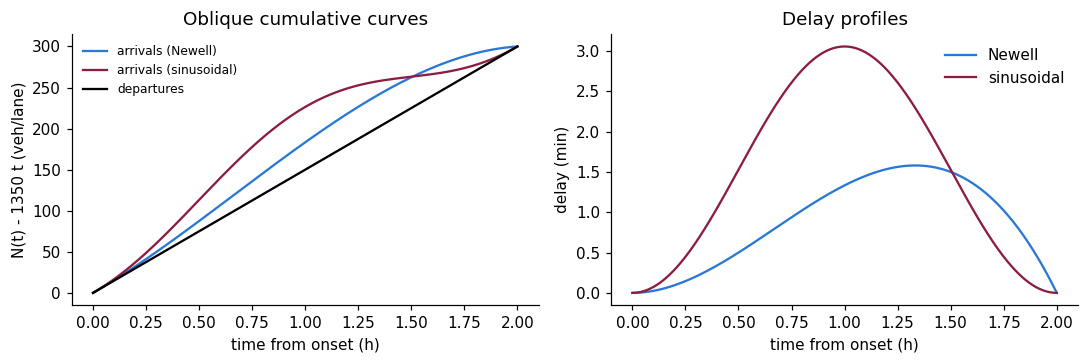

In [3]:
ref = 0.9 * mu
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for lam_, Q_, c, lab in ((n.lam(t), q['Q'], '#2a78d6', 'Newell'), (lam2, q2['Q'], '#8C1D40', 'sinusoidal')):
    ax[0].plot(t, mu * t + Q_ - ref * t, color=c, label=f'arrivals ({lab})')
ax[0].plot(t, mu * t - ref * t, color='k', label='departures')
ax[0].set(xlabel='time from onset (h)', ylabel=f'N(t) - {ref:.0f} t (veh/lane)', title='Oblique cumulative curves'); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(t, q['w'] * 60, color='#2a78d6', label='Newell'); ax[1].plot(t, q2['w'] * 60, color='#8C1D40', label='sinusoidal')
ax[1].set(xlabel='time from onset (h)', ylabel='delay (min)', title='Delay profiles'); ax[1].legend(frameon=False)
plt.tight_layout()

## 6. Interpretation question
Both profiles serve the same number of vehicles in the same duration. Which one has the larger total delay $W_P$, and why does $\bar w_P$ (not the peak delay) carry that information into an emission total?